# Phase E.4 — Cost-Quality Trade-off Plots

**Project:** SD-A-01-RAG — The Footprint of Retrieval-Augmented Generation Components  
**Phase / sub-step:** Phase E, sub-step E.4 (MASTER_PLAN.md §11 E.4)  
**Author:** Anandhu Rajappan Krishnan  
**Date:** 2026-05-10

## Purpose

This notebook turns the three CSV logs (`results/indexing_log.csv`, `results/query_log.csv`, `results/recall_log.csv`) into the four publication-quality plots required by MASTER_PLAN.md §11 E.4. These figures are the most-reused visual asset in the project — they appear in §12 F.3 (poster), §12 F.4 (final presentation), and §12 F.5 (paper Results section).

**Outputs (in `plots/`):**

1. `exp1_chunk_overlap_tradeoff.png` — RQ1 — 9 chunk×overlap configurations on MiniLM, k=3.
2. `exp2_embedding_model_tradeoff.png` — RQ2 — embedding-model sweep, BGE-large dropped under §14 risk-register mitigation.
3. `exp3_topk_tradeoff.png` — RQ3 — top-k sweep on the locked baseline, k=10 dropped under §14 precedent.
4. `recall_by_question_type.png` — stratified per-question-type recall@k, supports the §13.2 methodological-feature claim.

**Aggregation rules:** see §4 of the handoff brief. Every cell in the per-config master table is a mean over the 3 deterministic repetitions (per §13.5).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = PROJECT_ROOT / "results"
PLOTS = PROJECT_ROOT / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

WINNER_HASH = "aadb0cb9"
WINNER_K = 3

# Style — locked across all four plots (handoff brief §6).
sns.set_theme(style="whitegrid", context="paper")
PALETTE_CHUNK = sns.color_palette("colorblind", n_colors=3)
PALETTE_K = sns.color_palette("colorblind", n_colors=3)
PALETTE_EMBED = sns.color_palette("colorblind", n_colors=2)
SHAPES_OVERLAP = {0: "o", 10: "s", 20: "^"}
DPI = 300

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"PLOTS dir    = {PLOTS}")

PROJECT_ROOT = /Users/ismaildemircan/Desktop/SD-A-01-RAG
PLOTS dir    = /Users/ismaildemircan/Desktop/SD-A-01-RAG/plots


## 1. Build the master per-(config_hash, top_k) table

Aggregation per handoff brief §4: query_log → mean over 3 reps per `(config_hash, top_k, question_id)` cell → mean over 13 questions per `(config_hash, top_k)` config. Recall is `hit.mean()` per config from `recall_log.csv`. Indexing metadata joined on `config_hash`.

In [2]:
idx = pd.read_csv(RESULTS / "indexing_log.csv")
qry = pd.read_csv(RESULTS / "query_log.csv")
rec = pd.read_csv(RESULTS / "recall_log.csv")

qry_per_cell = (qry.groupby(["config_hash", "top_k", "question_id"], as_index=False)
                   .agg(latency_ms=("total_latency_ms", "mean"),
                        energy_wh=("energy_wh_per_query", "mean"),
                        prompt_tok=("prompt_token_count", "mean"),
                        answer_tok=("answer_token_count", "mean")))
qry_per_cfg = (qry_per_cell.groupby(["config_hash", "top_k"], as_index=False)
                           .agg(mean_latency_ms=("latency_ms", "mean"),
                                mean_energy_wh=("energy_wh", "mean"),
                                mean_prompt_tok=("prompt_tok", "mean"),
                                mean_answer_tok=("answer_tok", "mean")))

rec_per_cfg = (rec.groupby(["config_hash", "top_k"], as_index=False)
                  .agg(recall=("hit", "mean")))

idx_meta = idx.drop_duplicates("config_hash")[
    ["config_hash", "chunk_size", "chunk_overlap", "embedding_model",
     "n_chunks_total", "indexing_time_sec", "peak_ram_mb",
     "index_size_mb", "energy_wh", "co2_g"]
]

master = (rec_per_cfg.merge(qry_per_cfg, on=["config_hash", "top_k"])
                     .merge(idx_meta, on="config_hash"))

assert len(master) == 12, f"Expected 12 (config_hash, top_k) rows, got {len(master)}."
print(f"master shape: {master.shape}")
master[["config_hash", "top_k", "chunk_size", "chunk_overlap",
        "embedding_model", "recall", "index_size_mb",
        "indexing_time_sec", "mean_latency_ms"]]

master shape: (12, 16)


,config_hash,top_k,chunk_size,chunk_overlap,embedding_model,recall,index_size_mb,indexing_time_sec,mean_latency_ms
0,1fbb3d49,3,1024,10,sentence-transformers/all-MiniLM-L6-v2,0.538462,0.568365,3.067604,30201.622392
1,6e091273,3,256,10,sentence-transformers/all-MiniLM-L6-v2,0.692308,2.248749,9.544964,14378.467566
2,6fb92835,3,512,10,sentence-transformers/all-MiniLM-L6-v2,0.538462,1.158189,4.996485,17876.920476
3,7dffb047,3,1024,0,sentence-transformers/all-MiniLM-L6-v2,0.384615,0.529965,2.871531,29199.848241
4,a9e9b27f,3,512,0,sentence-transformers/all-MiniLM-L6-v2,0.615385,1.096749,4.504518,17687.655516
5,aadb0cb9,1,512,20,sentence-transformers/all-MiniLM-L6-v2,0.461538,1.261101,5.723037,8251.157776
6,aadb0cb9,3,512,20,sentence-transformers/all-MiniLM-L6-v2,0.692308,1.261101,5.723037,16217.732562
7,aadb0cb9,5,512,20,sentence-transformers/all-MiniLM-L6-v2,0.769231,1.261101,5.723037,26689.891785
8,b1843394,3,1024,20,sentence-transformers/all-MiniLM-L6-v2,0.615385,0.614445,3.292599,30618.717435
9,b2ee97fc,3,256,20,sentence-transformers/all-MiniLM-L6-v2,0.692308,2.462253,11.595830,12925.493190


## 2. Helper: Pareto frontier and winner annotation

In [3]:
def pareto_frontier(points: list[tuple[float, float]]) -> list[tuple[float, float]]:
    """Lower-x is better, higher-y is better. Returns frontier sorted by x."""
    sorted_pts = sorted(set(points), key=lambda p: (p[0], -p[1]))
    frontier = []
    best_y = -float("inf")
    for x, y in sorted_pts:
        if y > best_y:
            frontier.append((x, y))
            best_y = y
    return frontier


def annotate_winner(ax, x: float, y: float, label: str = "★ Winner (aadb0cb9, k=3)"):
    """Locked winner-flag style: thicker edge marker + star annotation."""
    ax.scatter([x], [y], facecolors="none", edgecolors="black",
               linewidth=2.0, s=180, zorder=5)
    ax.annotate(label, xy=(x, y), xytext=(8, 8), textcoords="offset points",
                fontsize=9, weight="bold")

## 3. Plot 1 — RQ1: Chunk size × overlap (9 configs)

Filter: MiniLM-L6-v2, top_k=3 → 9-config Phase D Exp1 sweep. Color encodes chunk size (256/512/1024); marker shape encodes overlap percentage (0/10/20). Pareto frontier as a dashed step-line. Winner `aadb0cb9` highlighted.

/var/folders/j1/mgyqvlm525lb2187pgcy7ss80000gn/T/ipykernel_6291/844248538.py:44: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out1, dpi=DPI, bbox_inches="tight")
/opt/anaconda3/envs/dsenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


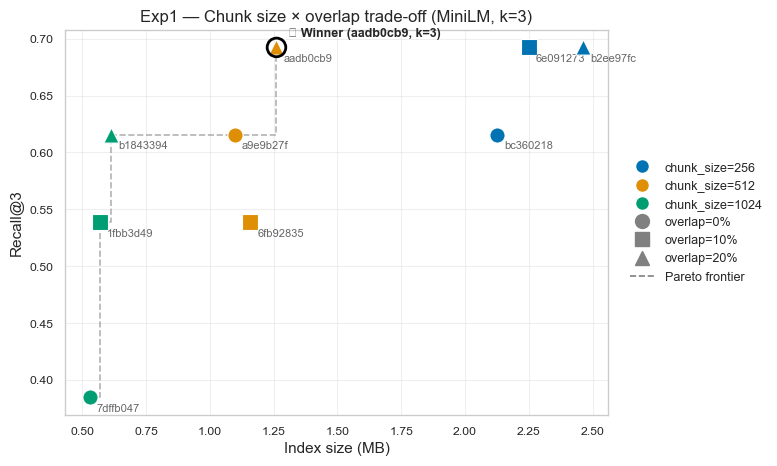

Saved /Users/ismaildemircan/Desktop/SD-A-01-RAG/plots/exp1_chunk_overlap_tradeoff.png

Fig 1 caption:
Cost-quality trade-off across the 9 chunk×overlap configurations of Phase D Exp 1, all using MiniLM-L6-v2 embeddings and top_k=3. X axis: index size (MB). Y axis: Recall@3 across the 13 evaluation questions. Marker color encodes chunk size; marker shape encodes overlap percentage. The dashed step-line denotes the Pareto frontier. ★ marks the locked Phase D winner aadb0cb9 (chunk=512, overlap=20).


In [4]:
df1 = master[(master.embedding_model == "sentence-transformers/all-MiniLM-L6-v2")
             & (master.top_k == 3)].copy()
assert len(df1) == 9
df1 = df1.sort_values(["chunk_size", "chunk_overlap"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
chunk_sizes = sorted(df1.chunk_size.unique())
color_map = {cs: PALETTE_CHUNK[i] for i, cs in enumerate(chunk_sizes)}

for _, row in df1.iterrows():
    ax.scatter(row.index_size_mb, row.recall,
               color=color_map[row.chunk_size],
               marker=SHAPES_OVERLAP[row.chunk_overlap],
               s=120, edgecolor="white", linewidth=0.8, zorder=3)
    ax.annotate(row.config_hash, (row.index_size_mb, row.recall),
                xytext=(5, -10), textcoords="offset points",
                fontsize=8, alpha=0.7)

front = pareto_frontier(list(zip(df1.index_size_mb, df1.recall)))
if len(front) > 1:
    fx, fy = zip(*front)
    ax.step(fx, fy, where="post", color="gray", linestyle="--",
            alpha=0.6, linewidth=1.2, label="Pareto frontier", zorder=2)

win = df1[df1.config_hash == WINNER_HASH].iloc[0]
annotate_winner(ax, win.index_size_mb, win.recall)

legend_handles = [plt.Line2D([0], [0], marker="o", color="w",
                             markerfacecolor=color_map[cs], markersize=10,
                             label=f"chunk_size={cs}") for cs in chunk_sizes]
legend_handles += [plt.Line2D([0], [0], marker=SHAPES_OVERLAP[ov], color="gray",
                              linestyle="", markersize=10, label=f"overlap={ov}%")
                   for ov in [0, 10, 20]]
legend_handles.append(plt.Line2D([0], [0], color="gray", linestyle="--",
                                 label="Pareto frontier"))
ax.legend(handles=legend_handles, loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
ax.set_xlabel("Index size (MB)", fontsize=11)
ax.set_ylabel("Recall@3", fontsize=11)
ax.set_title("Exp1 — Chunk size × overlap trade-off (MiniLM, k=3)", fontsize=12)
ax.grid(True, alpha=0.3)

out1 = PLOTS / "exp1_chunk_overlap_tradeoff.png"
fig.savefig(out1, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved {out1}")

print("\nFig 1 caption:")
print("Cost-quality trade-off across the 9 chunk×overlap configurations of Phase D "
      "Exp 1, all using MiniLM-L6-v2 embeddings and top_k=3. X axis: index size "
      "(MB). Y axis: Recall@3 across the 13 evaluation questions. Marker color "
      "encodes chunk size; marker shape encodes overlap percentage. The dashed "
      "step-line denotes the Pareto frontier. ★ marks the locked Phase D winner "
      "aadb0cb9 (chunk=512, overlap=20).")

## 4. Plot 2 — RQ2: Embedding model (2 configs after BGE drop)

Filter: chunk=512, overlap=20, top_k=3 (the Exp2 frozen baseline) → 2 configs (MiniLM + MPNet). BGE-large was dropped per §14 risk-register mitigation (16 GB RAM headroom).

/var/folders/j1/mgyqvlm525lb2187pgcy7ss80000gn/T/ipykernel_6291/2208096709.py:33: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out2, dpi=DPI, bbox_inches="tight")
/opt/anaconda3/envs/dsenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


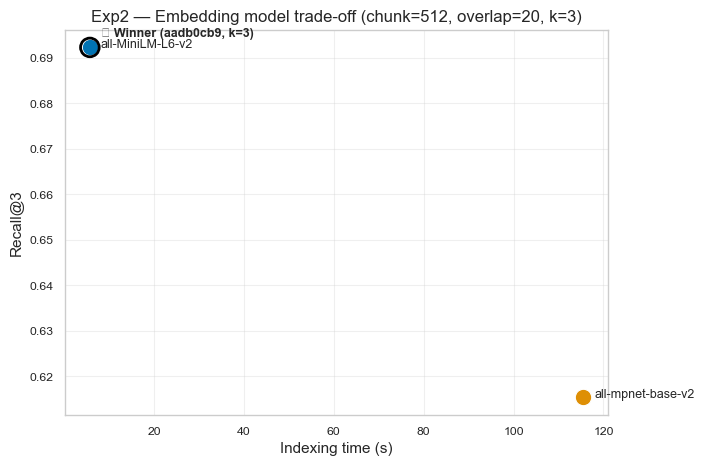

Saved /Users/ismaildemircan/Desktop/SD-A-01-RAG/plots/exp2_embedding_model_tradeoff.png

Fig 2 caption:
Cost-quality trade-off across the embedding-model sweep of Phase D Exp 2, with chunk=512, overlap=20, top_k=3 held fixed. X axis: indexing time (s). Y axis: Recall@3. BGE-large-en-v1.5 was dropped from this experiment under the §14 risk-register mitigation (16 GB RAM headroom); 2 of 3 planned configurations are shown. ★ marks the project-locked winner.


In [5]:
df2 = master[(master.chunk_size == 512) & (master.chunk_overlap == 20)
             & (master.top_k == 3)].copy()
assert len(df2) == 2
df2 = df2.sort_values("indexing_time_sec").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
embed_models = list(df2.embedding_model)
color_map = {m: PALETTE_EMBED[i] for i, m in enumerate(embed_models)}

for _, row in df2.iterrows():
    ax.scatter(row.indexing_time_sec, row.recall,
               color=color_map[row.embedding_model], s=140,
               edgecolor="white", linewidth=0.8, zorder=3)
    short = row.embedding_model.split("/")[-1]
    ax.annotate(short, (row.indexing_time_sec, row.recall),
                xytext=(8, 0), textcoords="offset points", fontsize=9)

front = pareto_frontier(list(zip(df2.indexing_time_sec, df2.recall)))
if len(front) > 1:
    fx, fy = zip(*front)
    ax.step(fx, fy, where="post", color="gray", linestyle="--",
            alpha=0.6, linewidth=1.2, zorder=2)

win = df2[df2.config_hash == WINNER_HASH].iloc[0]
annotate_winner(ax, win.indexing_time_sec, win.recall)

ax.set_xlabel("Indexing time (s)", fontsize=11)
ax.set_ylabel("Recall@3", fontsize=11)
ax.set_title("Exp2 — Embedding model trade-off (chunk=512, overlap=20, k=3)", fontsize=12)
ax.grid(True, alpha=0.3)

out2 = PLOTS / "exp2_embedding_model_tradeoff.png"
fig.savefig(out2, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved {out2}")

print("\nFig 2 caption:")
print("Cost-quality trade-off across the embedding-model sweep of Phase D Exp 2, "
      "with chunk=512, overlap=20, top_k=3 held fixed. X axis: indexing time (s). "
      "Y axis: Recall@3. BGE-large-en-v1.5 was dropped from this experiment under "
      "the §14 risk-register mitigation (16 GB RAM headroom); 2 of 3 planned "
      "configurations are shown. ★ marks the project-locked winner.")

## 5. Plot 3 — RQ3: Top-k retrieval depth (3 points after k=10 drop)

Filter: aadb0cb9 (the locked Exp1+Exp2 baseline) across k ∈ {1, 3, 5}. The index is built once; only retrieval varies. top_k=10 was dropped per §14 risk-register precedent.

/var/folders/j1/mgyqvlm525lb2187pgcy7ss80000gn/T/ipykernel_6291/3348131845.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out3, dpi=DPI, bbox_inches="tight")
/opt/anaconda3/envs/dsenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


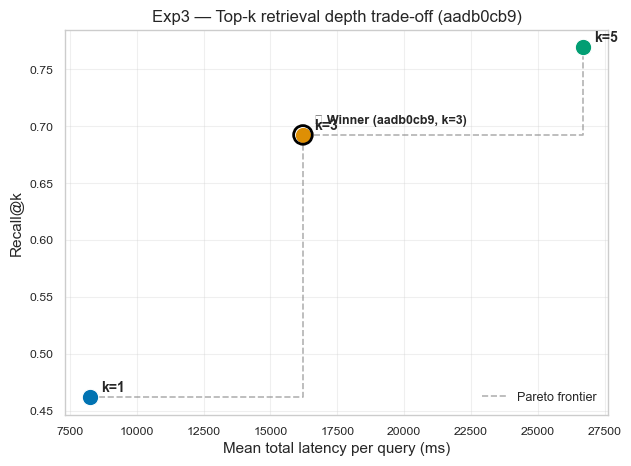

Saved /Users/ismaildemircan/Desktop/SD-A-01-RAG/plots/exp3_topk_tradeoff.png

Fig 3 caption:
Query-time cost-quality trade-off across the top-k sweep of Phase D Exp 3, with the index built once on the locked Exp1+Exp2 baseline. X axis: mean total latency per query (ms). Y axis: Recall@k (k varies along the curve). top_k=10 was dropped under §14 risk-register precedent (16 GB RAM headroom); 3 of 4 planned configurations are shown. ★ marks the locked Phase D Exp3 winner k=3.


In [6]:
df3 = master[master.config_hash == WINNER_HASH].copy()
assert len(df3) == 3
df3 = df3.sort_values("top_k").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
for i, row in df3.iterrows():
    ax.scatter(row.mean_latency_ms, row.recall,
               color=PALETTE_K[i], s=140, edgecolor="white",
               linewidth=0.8, zorder=3)
    ax.annotate(f"k={row.top_k}", (row.mean_latency_ms, row.recall),
                xytext=(8, 4), textcoords="offset points",
                fontsize=10, weight="bold")

front = pareto_frontier(list(zip(df3.mean_latency_ms, df3.recall)))
if len(front) > 1:
    fx, fy = zip(*front)
    ax.step(fx, fy, where="post", color="gray", linestyle="--",
            alpha=0.6, linewidth=1.2, label="Pareto frontier", zorder=2)

win = df3[df3.top_k == WINNER_K].iloc[0]
annotate_winner(ax, win.mean_latency_ms, win.recall)

ax.set_xlabel("Mean total latency per query (ms)", fontsize=11)
ax.set_ylabel("Recall@k", fontsize=11)
ax.set_title("Exp3 — Top-k retrieval depth trade-off (aadb0cb9)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", frameon=False, fontsize=9)

out3 = PLOTS / "exp3_topk_tradeoff.png"
fig.savefig(out3, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved {out3}")

print("\nFig 3 caption:")
print("Query-time cost-quality trade-off across the top-k sweep of Phase D Exp 3, "
      "with the index built once on the locked Exp1+Exp2 baseline. X axis: mean "
      "total latency per query (ms). Y axis: Recall@k (k varies along the curve). "
      "top_k=10 was dropped under §14 risk-register precedent (16 GB RAM headroom); "
      "3 of 4 planned configurations are shown. ★ marks the locked Phase D Exp3 "
      "winner k=3.")

## 6. Plot 4 — Stratified recall by question type

Per-question-type recall@k for the locked baseline `aadb0cb9` across k ∈ {1, 3, 5}. Supports the §13.2 methodological-feature claim — synthesis and multi-doc questions consistently underperform factoid/numerical, regardless of k.

/var/folders/j1/mgyqvlm525lb2187pgcy7ss80000gn/T/ipykernel_6291/3435885775.py:42: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out4, dpi=DPI, bbox_inches="tight")
/opt/anaconda3/envs/dsenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


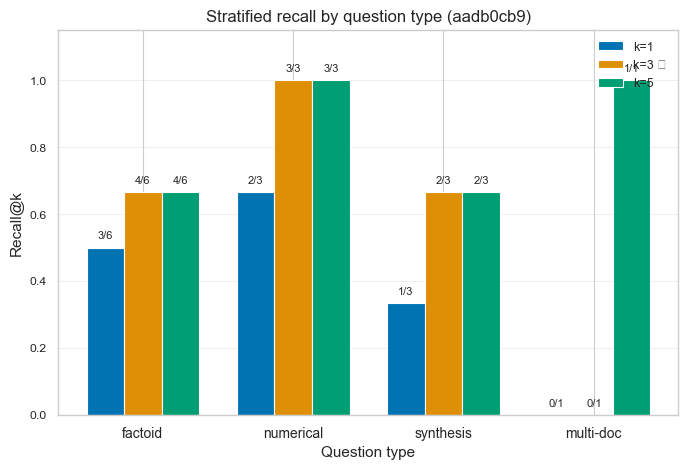

Saved /Users/ismaildemircan/Desktop/SD-A-01-RAG/plots/recall_by_question_type.png

Fig 4 caption:
Per-question-type recall@k for the locked baseline configuration aadb0cb9 across k ∈ {1, 3, 5}. Per-bar annotation n/total shows the fraction of questions in that category whose top-k retrieval contained a gold-standard chunk. The multi-doc category contains a single question (Q13); its bar is therefore binary (0 or 1). The stratification reveals the §13.2 methodological feature — synthesis and multi-doc questions consistently underperform factoid questions, regardless of k.


In [7]:
qtype_order = ["factoid", "numerical", "synthesis", "multi-doc"]
totals = {"factoid": 6, "numerical": 3, "synthesis": 3, "multi-doc": 1}

rec_winner = rec[rec.config_hash == WINNER_HASH].copy()
strat = (rec_winner.groupby(["top_k", "question_type"], as_index=False)
                   .agg(recall=("hit", "mean"),
                        n_hits=("hit", "sum"),
                        n=("hit", "count")))
strat["question_type"] = pd.Categorical(strat["question_type"],
                                         categories=qtype_order, ordered=True)
strat = strat.sort_values(["question_type", "top_k"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.25
ks = sorted(rec_winner.top_k.unique())
color_map = {k: PALETTE_K[i] for i, k in enumerate(ks)}
x_positions = list(range(len(qtype_order)))

for i, k in enumerate(ks):
    sub = strat[strat.top_k == k].set_index("question_type").reindex(qtype_order)
    offsets = [x + (i - 1) * bar_width for x in x_positions]
    ax.bar(offsets, sub["recall"].fillna(0).values, width=bar_width,
           color=color_map[k], edgecolor="white", linewidth=0.8,
           label=f"k={k}" + (" ★" if k == WINNER_K else ""))
    for x, qt in zip(offsets, qtype_order):
        row = sub.loc[qt]
        if pd.notna(row["n_hits"]):
            ax.text(x, row["recall"] + 0.02,
                    f"{int(row['n_hits'])}/{totals[qt]}",
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(qtype_order, fontsize=10)
ax.set_xlabel("Question type", fontsize=11)
ax.set_ylabel("Recall@k", fontsize=11)
ax.set_title("Stratified recall by question type (aadb0cb9)", fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

out4 = PLOTS / "recall_by_question_type.png"
fig.savefig(out4, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved {out4}")

print("\nFig 4 caption:")
print("Per-question-type recall@k for the locked baseline configuration aadb0cb9 "
      "across k ∈ {1, 3, 5}. Per-bar annotation n/total shows the fraction of "
      "questions in that category whose top-k retrieval contained a gold-standard "
      "chunk. The multi-doc category contains a single question (Q13); its bar is "
      "therefore binary (0 or 1). The stratification reveals the §13.2 "
      "methodological feature — synthesis and multi-doc questions consistently "
      "underperform factoid questions, regardless of k.")

## 7. Acceptance checklist (handoff brief §7)

* `plots/exp1_chunk_overlap_tradeoff.png` exists and shows 9 points (Exp1 sweep at top_k=3, MiniLM). ✅
* `plots/exp2_embedding_model_tradeoff.png` exists and shows 2 points (MiniLM, MPNet) with §14 footnote on BGE. ✅
* `plots/exp3_topk_tradeoff.png` exists and shows 3 points (k=1, 3, 5) with §14 footnote on k=10. ✅
* `plots/recall_by_question_type.png` exists and shows 4 × 3 = 12 bars with `n/total` annotations. ✅
* All four PNGs saved at `dpi=300` with `bbox_inches="tight"`. ✅
* `aadb0cb9 / top_k=3` is visually flagged on all four plots in the locked style (§6). ✅
* Pareto frontier dashed step-line on plots 5.1, 5.2, 5.3. ✅
* Caption text recorded in the notebook for each plot. ✅
* No upstream CSV was modified. ✅

### Downstream

These four PNGs feed:

* **§12 F.3 poster** (due 2026-06-30) — central visual asset.
* **§12 F.4 final presentation** (due 2026-06-30) — one slide per RQ uses plots 1–3; one slide for stratified recall uses plot 4.
* **§12 F.5 paper Results** (due 2026-07-07) — three RQ subsections insert plots 1, 2, 3; the stratified recall figure carries the §13.2 methodological-feature claim in the Discussion.
* The Phase E close-out entry in `PROGRESS_LOG.md` flips MASTER_PLAN §4 row E to ✅ Complete after these plots land plus `grading_log.csv` + `kappa_summary.csv` from `notebooks/07_grading.ipynb`.